# Preprocessing, main-study, ablation, and I2T results

This notebook does not train or test models. It reads the files saved in Google Drive, reports arithmetic means across seeds 42, 95, and 1024, and directly renders the original I2T visualisation inside Colab.

In [26]:
# Mount Google Drive and install the project dependencies.
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/Dissertation/medical_vlm_fusion'
%cd $PROJECT_DIR
%pip -q install --no-cache-dir -r requirements.txt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Dissertation/medical_vlm_fusion


In [27]:
# Import result-display dependencies and define project paths.
%matplotlib inline
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_DIR = Path('/content/drive/MyDrive/Dissertation/medical_vlm_fusion')
ARTIFACTS_DIR = PROJECT_DIR / 'artifacts'
DATA_DIR = ARTIFACTS_DIR / 'data' / 'iu_xray_chexpert14'
RESULTS_ROOT_DIR = ARTIFACTS_DIR / 'results'
AVERAGED_DIR = RESULTS_ROOT_DIR / 'three_seed_average'
AVERAGED_DIR.mkdir(parents=True, exist_ok=True)

SEEDS = (42, 95, 1024)
MAIN_MODEL_NAMES = {
    'image_only': 'Image-only',
    'text_only': 'Text-only',
    'concat_fusion': 'Concatenation fusion',
    'average_fusion': 'Average fusion',
    'gated_fusion': 'Gated fusion',
    'self_attention_fusion': 'Self-attention fusion',
    'bidirectional_cross_attention': 'Bidirectional cross-attention',
}
ABLATION_MODEL_NAMES = {
    'bidirectional_cross_attention': 'Full bidirectional cross-attention',
    'bicross_i2t_only': 'Image-to-text only',
    'bicross_t2i_only': 'Text-to-image only',
    'bicross_no_cross_attention': 'No cross-attention',
    'bicross_no_residual_update': 'No residual update',
    'bicross_no_layer_norm': 'No layer normalization',
    'bicross_with_alignment_loss': 'Full bidirectional cross-attention + alignment loss',
}
PAPER_METRICS = [
    'macro_auroc', 'macro_ap', 'macro_f1', 'micro_f1',
    'label_accuracy', 'subset_accuracy', 'loss',
]

## IU X-ray CheXpert-14 preprocessing results

In [28]:
# Display the preprocessing metadata, label summary, and processed sample rows.
metadata_path = DATA_DIR / 'iu_xray_chexpert14_metadata.json'
summary_path = DATA_DIR / 'iu_xray_chexpert14_label_summary.csv'
binary_path = DATA_DIR / 'iu_xray_chexpert14_binary_u_zero.csv'

for required_path in (metadata_path, summary_path, binary_path):
    if not required_path.exists():
        raise FileNotFoundError(f'Missing preprocessing output: {required_path}')

with metadata_path.open() as handle:
    preprocessing_metadata = json.load(handle)
preprocessing_summary = pd.read_csv(summary_path)
processed_samples = pd.read_csv(binary_path)

display(pd.DataFrame([preprocessing_metadata]))
display(preprocessing_summary)
display(processed_samples.head(10))

,dataset_name,text_mode,only_frontal,uncertain_policy,num_samples,labels,raw_output_csv,binary_output_csv,summary_output_csv
0,raddar/chest-xrays-indiana-university,findings_impression,True,u_zero,3666,"[No Finding, Enlarged Cardiomediastinum, Cardi...",/content/drive/MyDrive/Dissertation/medical_vl...,/content/drive/MyDrive/Dissertation/medical_vl...,/content/drive/MyDrive/Dissertation/medical_vl...


,label,raw_positive_1,raw_negative_0,raw_uncertain_-1,raw_unmentioned_nan,binary_positive_after_policy,binary_prevalence_after_policy
0,No Finding,1834,3098,0,1200,917,0.250136
1,Enlarged Cardiomediastinum,16,66,4,3623,8,0.002182
2,Cardiomegaly,480,74,12,3383,240,0.065466
3,Lung Lesion,930,312,122,2984,465,0.126841
4,Lung Opacity,730,1416,268,2459,365,0.099564
5,Edema,156,524,26,3313,78,0.021277
6,Consolidation,66,2134,124,2504,33,0.009002
7,Pneumonia,194,220,170,3374,97,0.026459
8,Atelectasis,606,30,82,3307,303,0.082651
9,Pneumothorax,134,4488,122,1294,67,0.018276


,uid,filename,projection,image_path_at_preprocessing,text,text_len,findings,impression,indication,mesh,...,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,num_positive_labels,has_any_positive
0,1,1_IM-0001-4001.dcm.png,Frontal,/kaggle/input/chest-xrays-indiana-university/i...,Findings: The cardiac silhouette and mediastin...,253,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.,Positive TB test,normal,...,0,0,0,0,0,0,0,0,1,1
1,2,2_IM-0652-1001.dcm.png,Frontal,/kaggle/input/chest-xrays-indiana-university/i...,Findings: Borderline cardiomegaly. Midline ste...,167,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.,Preop bariatric surgery.,Cardiomegaly/borderline;Pulmonary Artery/enlarged,...,0,0,0,0,0,0,0,1,2,1
2,3,3_IM-1384-1001.dcm.png,Frontal,/kaggle/input/chest-xrays-indiana-university/i...,"Impression: No displaced rib fractures, pneumo...",207,NaN,"No displaced rib fractures, pneumothorax, or p...","rib pain after a XXXX, XXXX XXXX steps this XX...",normal,...,0,0,0,0,0,0,0,0,1,1
3,4,4_IM-2050-1001.dcm.png,Frontal,/kaggle/input/chest-xrays-indiana-university/i...,Findings: There are diffuse bilateral intersti...,781,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...,XXXX-year-old XXXX with XXXX.,"Pulmonary Disease, Chronic Obstructive;Bullous...",...,0,0,0,0,0,0,0,0,0,0
4,5,5_IM-2117-1003002.dcm.png,Frontal,/kaggle/input/chest-xrays-indiana-university/i...,Findings: The cardiomediastinal silhouette and...,383,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.,Chest and nasal congestion.,Osteophyte/thoracic vertebrae/multiple/small;T...,...,0,0,0,0,0,1,0,0,1,1
5,6,6_IM-2192-1001.dcm.png,Frontal,/kaggle/input/chest-xrays-indiana-university/i...,Findings: Heart size and mediastinal contour a...,282,Heart size and mediastinal contour are within ...,No acute cardiopulmonary findings.,Evaluate for infection,normal,...,0,0,0,0,0,0,0,0,0,0
6,7,7_IM-2263-1001.dcm.png,Frontal,/kaggle/input/chest-xrays-indiana-university/i...,Findings: The cardiac contours are normal. XXX...,229,The cardiac contours are normal. XXXX basilar ...,Basilar atelectasis. No confluent lobar consol...,Preop lumbar surgery,Pulmonary Atelectasis/base;Spondylosis/thoraci...,...,0,0,1,0,0,0,0,0,1,1
7,8,8_IM-2333-1001.dcm.png,Frontal,/kaggle/input/chest-xrays-indiana-university/i...,"Findings: The heart, pulmonary XXXX and medias...",295,"The heart, pulmonary XXXX and mediastinum are ...",No acute cardiopulmonary disease.,XXXX-year-old with XXXX on XXXX. Dyspnea. Hist...,normal,...,0,0,0,0,0,0,0,0,0,0
8,9,9_IM-2407-1001.dcm.png,Frontal,/kaggle/input/chest-xrays-indiana-university/i...,Findings: The XXXX examination consists of fro...,759,The XXXX examination consists of frontal and l...,Increased size of density in the left cardioph...,Chest pain today. History of stent placement 7...,Calcified Granuloma/lung/upper lobe/right;Dens...,...,0,0,0,0,0,0,0,0,1,1
9,10,10_IM-0002-2001.dcm.png,Frontal,/kaggle/input/chest-xrays-indiana-university/i...,Findings: The cardiomediastinal silhouette is ...,329,The cardiomediastinal silhouette is within nor...,No acute cardiopulmonary process.,"XXXX-year-old male, chest pain.",Calcified Granuloma/lung/upper lobe/right,...,0,0,0,0,0,0,0,0,1,1


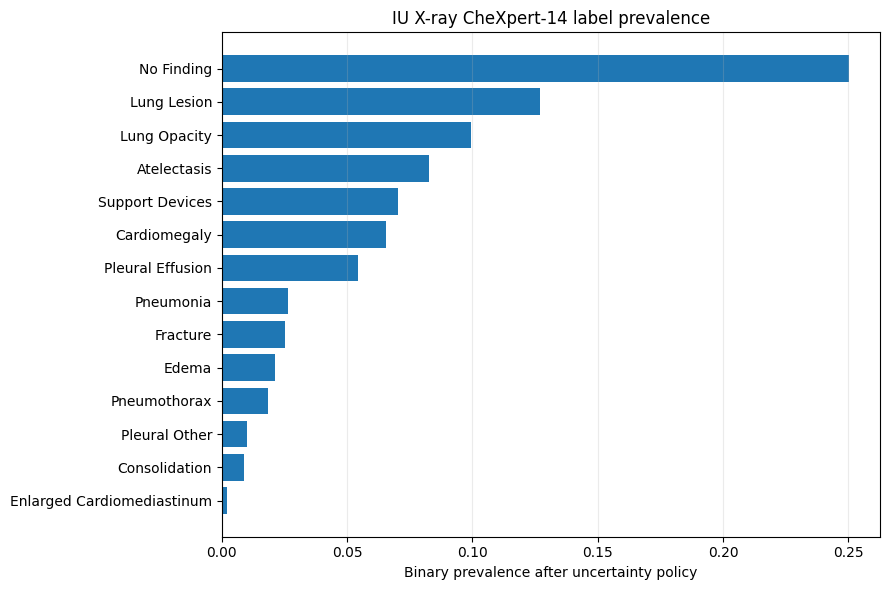

In [29]:
# Plot the positive-label prevalence produced by the preprocessing logic.
prevalence = preprocessing_summary.sort_values('binary_prevalence_after_policy', ascending=True)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(prevalence['label'], prevalence['binary_prevalence_after_policy'])
ax.set_xlabel('Binary prevalence after uncertainty policy')
ax.set_title('IU X-ray CheXpert-14 label prevalence')
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()
figure_path = AVERAGED_DIR / 'preprocessing_label_prevalence.png'
fig.savefig(figure_path, dpi=200, bbox_inches='tight')
plt.show()

## Load and verify the three-seed result files

The next cell verifies that every main and ablation model has exactly one saved result for each required seed before any mean is calculated.

In [30]:
# Read one result JSON file and retain scalar test metrics.
def load_result_row(seed, model_key):
    """Load one seed-specific model result as a flat row."""
    result_path = RESULTS_ROOT_DIR / f'exp_seed_{seed}' / f'{model_key}_result.json'
    if not result_path.exists():
        raise FileNotFoundError(f'Missing result file: {result_path}')
    with result_path.open() as handle:
        payload = json.load(handle)
    metrics = payload.get('test_metrics', {})
    row = {'seed': seed, 'model_key': model_key}
    row.update({key: value for key, value in metrics.items() if not isinstance(value, dict)})
    return row


# Load each unique model once per seed; the full BiCross model is shared by both comparisons.
EXPECTED_MODEL_KEYS = list(dict.fromkeys([*MAIN_MODEL_NAMES, *ABLATION_MODEL_NAMES]))
result_rows = [
    load_result_row(seed, model_key)
    for seed in SEEDS
    for model_key in EXPECTED_MODEL_KEYS
]
all_seed_results = pd.DataFrame(result_rows)

# Reject incomplete or duplicated seed sets instead of silently averaging fewer than three runs.
for model_key in EXPECTED_MODEL_KEYS:
    model_rows = all_seed_results[all_seed_results['model_key'] == model_key]
    actual_seeds = tuple(sorted(model_rows['seed'].tolist()))
    if actual_seeds != tuple(sorted(SEEDS)):
        raise ValueError(
            f'{model_key} must contain seeds {SEEDS}, but found {actual_seeds}.'
        )

print(f'Validated {len(all_seed_results)} result files across seeds {SEEDS}.')

Validated 39 result files across seeds (42, 95, 1024).


In [31]:
# Build a three-seed mean table for one ordered experiment group.
def build_mean_table(seed_table, model_names):
    """Average numeric metrics and attach canonical display names."""
    numeric_columns = [
        column for column in seed_table.select_dtypes(include=[np.number]).columns
        if column != 'seed'
    ]
    mean_table = (
        seed_table.groupby('model_key', as_index=False)[numeric_columns]
        .mean()
    )
    mean_table.insert(1, 'model', mean_table['model_key'].map(model_names))
    mean_table.insert(2, 'seeds', ','.join(str(seed) for seed in SEEDS))
    show_columns = [
        'model_key', 'model', 'seeds',
        *[metric for metric in PAPER_METRICS if metric in mean_table.columns],
    ]
    return mean_table[show_columns].sort_values(
        'macro_auroc', ascending=False, na_position='last'
    )


# Draw the principal metrics with an optional lower y-axis limit.
def plot_mean_metrics(table, title, filename, y_min=None):
    """Plot three-seed mean AUROC, AP, and F1 with an optional lower limit."""
    plot_table = table.sort_values('macro_auroc', ascending=False).copy()
    metrics = ['macro_auroc', 'macro_ap', 'macro_f1']
    x = np.arange(len(plot_table))
    width = 0.25
    fig, ax = plt.subplots(figsize=(13, 6))
    for index, metric in enumerate(metrics):
        bars = ax.bar(
            x + (index - 1) * width,
            plot_table[metric],
            width,
            label=metric.replace('_', ' ').title(),
        )
        ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_table['model'], rotation=28, ha='right')
    if y_min is not None:
        ax.set_ylim(y_min, 1.03)
        ax.set_yticks(np.arange(y_min, 1.01, 0.1))
    ax.set_ylabel('Three-seed mean score')
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.25)
    ax.legend(frameon=False, ncol=3)
    fig.tight_layout()
    fig.savefig(AVERAGED_DIR / filename, dpi=200, bbox_inches='tight')
    plt.show()


# Average disease-level AUROC and AP for one experiment group.
def build_per_label_mean(model_names):
    """Average per-label AUROC and AP across all three required seeds."""
    rows = []
    for seed in SEEDS:
        for model_key in model_names:
            result_path = RESULTS_ROOT_DIR / f'exp_seed_{seed}' / f'{model_key}_result.json'
            with result_path.open() as handle:
                payload = json.load(handle)
            metrics = payload.get('test_metrics', {})
            auroc_values = metrics.get('per_label_auroc', {})
            ap_values = metrics.get('per_label_ap', {})
            for label in sorted(set(auroc_values) | set(ap_values)):
                rows.append({
                    'seed': seed,
                    'model_key': model_key,
                    'model': model_names[model_key],
                    'label': label,
                    'auroc': auroc_values.get(label, np.nan),
                    'ap': ap_values.get(label, np.nan),
                })
    per_seed = pd.DataFrame(rows)
    return (
        per_seed.groupby(['model_key', 'model', 'label'], as_index=False)[['auroc', 'ap']]
        .mean()
    )


# Average and plot saved epoch histories for one experiment group.
def show_mean_histories(model_names, filename_prefix, title_prefix):
    """Display three-seed mean validation AUROC and loss histories."""
    rows = []
    for seed in SEEDS:
        for model_key in model_names:
            history_path = RESULTS_ROOT_DIR / f'exp_seed_{seed}' / f'{model_key}_history.csv'
            if not history_path.exists():
                continue
            history = pd.read_csv(history_path)
            history.insert(0, 'seed', seed)
            history.insert(1, 'model_key', model_key)
            rows.append(history)
    if not rows:
        print('No history CSV files were found for this experiment group.')
        return pd.DataFrame()

    histories = pd.concat(rows, ignore_index=True)
    numeric_columns = [
        column for column in histories.select_dtypes(include=[np.number]).columns
        if column not in ('seed', 'epoch')
    ]
    mean_histories = histories.groupby(
        ['model_key', 'epoch'], as_index=False
    )[numeric_columns].mean()
    mean_histories.to_csv(
        AVERAGED_DIR / f'{filename_prefix}_three_seed_mean_histories.csv',
        index=False,
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for model_key, history in mean_histories.groupby('model_key'):
        display_name = model_names[model_key]
        if 'val_macro_auroc' in history:
            axes[0].plot(
                history['epoch'], history['val_macro_auroc'],
                marker='o', label=display_name,
            )
        if 'train_loss' in history and 'val_loss' in history:
            axes[1].plot(history['epoch'], history['train_loss'], label=f'{display_name} train')
            axes[1].plot(
                history['epoch'], history['val_loss'],
                linestyle='--', label=f'{display_name} val',
            )
    axes[0].set_title(f'{title_prefix}: validation Macro AUROC')
    axes[1].set_title(f'{title_prefix}: training and validation loss')
    for axis in axes:
        axis.set_xlabel('Epoch')
        axis.grid(alpha=0.25)
        axis.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, frameon=False)
    fig.tight_layout()
    fig.savefig(
        AVERAGED_DIR / f'{filename_prefix}_three_seed_mean_validation_dynamics.png',
        dpi=200,
        bbox_inches='tight',
    )
    plt.show()
    return mean_histories

## Main experiment results

All seven main-study models are shown below before the ablation results.

In [32]:
# Display every seed-level main result and its three-seed arithmetic mean.
main_seed_results = all_seed_results[
    all_seed_results['model_key'].isin(MAIN_MODEL_NAMES)
].copy()
main_seed_results.insert(
    2, 'model', main_seed_results['model_key'].map(MAIN_MODEL_NAMES)
)
main_seed_columns = [
    'seed', 'model_key', 'model',
    *[metric for metric in PAPER_METRICS if metric in main_seed_results.columns],
]
display(main_seed_results[main_seed_columns].sort_values(['seed', 'model_key']).round(4))

main_table = build_mean_table(main_seed_results, MAIN_MODEL_NAMES)
display(main_table.round(4))
main_table.to_csv(AVERAGED_DIR / 'main_three_seed_mean.csv', index=False)

,seed,model_key,model,macro_auroc,macro_ap,macro_f1,micro_f1,label_accuracy,subset_accuracy,loss
3,42,average_fusion,Average fusion,0.9236,0.4137,0.3762,0.5083,0.9116,0.3709,0.5246
6,42,bidirectional_cross_attention,Bidirectional cross-attention,0.9754,0.7308,0.6962,0.8306,0.9784,0.7618,0.4295
2,42,concat_fusion,Concatenation fusion,0.9222,0.4451,0.4334,0.5582,0.9319,0.4455,0.6164
4,42,gated_fusion,Gated fusion,0.9174,0.4253,0.3748,0.5111,0.9113,0.3600,0.5922
0,42,image_only,Image-only,0.8270,0.2649,0.2906,0.3910,0.8839,0.2218,0.7226
5,42,self_attention_fusion,Self-attention fusion,0.9607,0.7394,0.6661,0.7582,0.9675,0.6691,0.3015
1,42,text_only,Text-only,0.9230,0.4251,0.3614,0.4897,0.9001,0.3582,0.4856
16,95,average_fusion,Average fusion,0.9078,0.4493,0.3946,0.5089,0.9103,0.3691,0.5779
19,95,bidirectional_cross_attention,Bidirectional cross-attention,0.9536,0.7387,0.6726,0.8037,0.9752,0.7400,0.5222
15,95,concat_fusion,Concatenation fusion,0.9068,0.4639,0.4142,0.5280,0.9213,0.4564,0.6099


,model_key,model,seeds,macro_auroc,macro_ap,macro_f1,micro_f1,label_accuracy,subset_accuracy,loss
1,bidirectional_cross_attention,Bidirectional cross-attention,"42,95,1024",0.9624,0.7506,0.6841,0.8158,0.9762,0.7388,0.5013
5,self_attention_fusion,Self-attention fusion,"42,95,1024",0.9526,0.7363,0.6461,0.7332,0.9609,0.5994,0.3755
6,text_only,Text-only,"42,95,1024",0.9167,0.4407,0.3850,0.5000,0.9052,0.3618,0.5404
0,average_fusion,Average fusion,"42,95,1024",0.9136,0.4349,0.3940,0.5139,0.9162,0.3818,0.5882
3,gated_fusion,Gated fusion,"42,95,1024",0.9120,0.4439,0.3930,0.5110,0.9129,0.3352,0.7168
2,concat_fusion,Concatenation fusion,"42,95,1024",0.9108,0.4682,0.4274,0.5468,0.9274,0.4382,0.6718
4,image_only,Image-only,"42,95,1024",0.8100,0.2633,0.2688,0.3694,0.8740,0.1952,0.7790


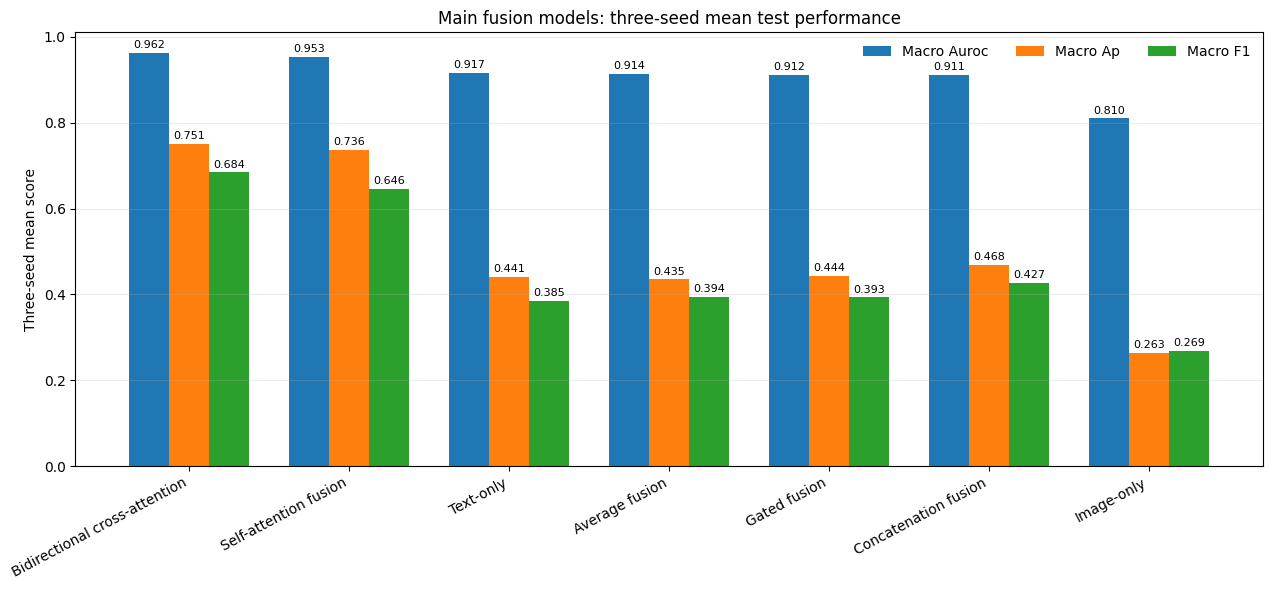

In [33]:
# Plot all main-study models with the original automatic score scale.
plot_mean_metrics(
    main_table,
    'Main fusion models: three-seed mean test performance',
    'main_three_seed_mean.png',
)

In [34]:
# Display disease-level three-seed mean metrics for every main-study model.
main_per_label_mean = build_per_label_mean(MAIN_MODEL_NAMES)
main_per_label_mean.to_csv(
    AVERAGED_DIR / 'main_three_seed_mean_per_label_metrics.csv',
    index=False,
)
display(main_per_label_mean.round(4))

,model_key,model,label,auroc,ap
0,average_fusion,Average fusion,Atelectasis,0.9385,0.5906
1,average_fusion,Average fusion,Cardiomegaly,0.9676,0.7139
2,average_fusion,Average fusion,Consolidation,0.8782,0.1389
3,average_fusion,Average fusion,Edema,0.9766,0.5439
4,average_fusion,Average fusion,Enlarged Cardiomediastinum,0.9542,0.0695
...,...,...,...,...,...
93,text_only,Text-only,Pleural Effusion,0.9431,0.5582
94,text_only,Text-only,Pleural Other,0.8615,0.0804
95,text_only,Text-only,Pneumonia,0.9141,0.2520
96,text_only,Text-only,Pneumothorax,0.9560,0.7437


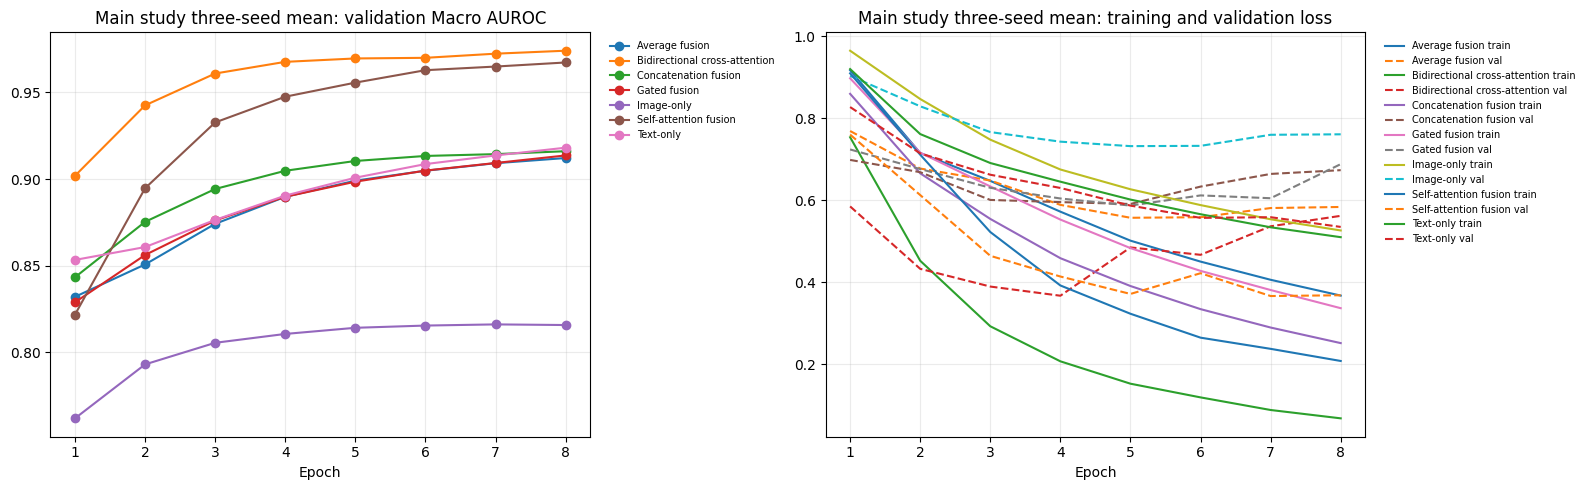

In [35]:
# Display the saved three-seed mean training histories for the main study.
main_mean_histories = show_mean_histories(
    MAIN_MODEL_NAMES,
    filename_prefix='main',
    title_prefix='Main study three-seed mean',
)

## Ablation experiment results

The full bidirectional model is included as the reference, followed by all six ablation variants.

In [36]:
# Display every seed-level ablation result and its three-seed arithmetic mean.
ablation_seed_results = all_seed_results[
    all_seed_results['model_key'].isin(ABLATION_MODEL_NAMES)
].copy()
ablation_seed_results.insert(
    2, 'model', ablation_seed_results['model_key'].map(ABLATION_MODEL_NAMES)
)
ablation_seed_columns = [
    'seed', 'model_key', 'model',
    *[metric for metric in PAPER_METRICS if metric in ablation_seed_results.columns],
]
display(ablation_seed_results[ablation_seed_columns].sort_values(['seed', 'model_key']).round(4))

ablation_table = build_mean_table(ablation_seed_results, ABLATION_MODEL_NAMES)
display(ablation_table.round(4))
ablation_table.to_csv(AVERAGED_DIR / 'ablation_three_seed_mean.csv', index=False)

,seed,model_key,model,macro_auroc,macro_ap,macro_f1,micro_f1,label_accuracy,subset_accuracy,loss
7,42,bicross_i2t_only,Image-to-text only,0.9770,0.7432,0.6527,0.7782,0.9747,0.7345,0.5078
9,42,bicross_no_cross_attention,No cross-attention,0.9275,0.5138,0.4624,0.6086,0.9457,0.5200,0.8122
11,42,bicross_no_layer_norm,No layer normalization,0.9761,0.7347,0.6860,0.7926,0.9722,0.7145,0.2893
10,42,bicross_no_residual_update,No residual update,0.9783,0.7661,0.7287,0.8630,0.9827,0.8127,0.3615
8,42,bicross_t2i_only,Text-to-image only,0.9342,0.4748,0.4410,0.5227,0.9179,0.4345,0.4876
12,42,bicross_with_alignment_loss,Full bidirectional cross-attention + alignment...,0.9759,0.7535,0.6969,0.8332,0.9783,0.7673,0.3791
6,42,bidirectional_cross_attention,Full bidirectional cross-attention,0.9754,0.7308,0.6962,0.8306,0.9784,0.7618,0.4295
20,95,bicross_i2t_only,Image-to-text only,0.8873,0.4393,0.3450,0.4461,0.8765,0.3091,0.5777
22,95,bicross_no_cross_attention,No cross-attention,0.9271,0.5351,0.4589,0.5700,0.9314,0.4600,0.5438
24,95,bicross_no_layer_norm,No layer normalization,0.9451,0.7134,0.6638,0.7623,0.9662,0.6255,0.4602


,model_key,model,seeds,macro_auroc,macro_ap,macro_f1,micro_f1,label_accuracy,subset_accuracy,loss
3,bicross_no_residual_update,No residual update,"42,95,1024",0.9759,0.8077,0.7511,0.8603,0.9817,0.8042,0.3385
5,bicross_with_alignment_loss,Full bidirectional cross-attention + alignment...,"42,95,1024",0.9645,0.7619,0.7024,0.8227,0.9768,0.7521,0.4376
6,bidirectional_cross_attention,Full bidirectional cross-attention,"42,95,1024",0.9624,0.7506,0.6841,0.8158,0.9762,0.7388,0.5013
2,bicross_no_layer_norm,No layer normalization,"42,95,1024",0.9612,0.7393,0.6803,0.7833,0.9703,0.6776,0.4083
0,bicross_i2t_only,Image-to-text only,"42,95,1024",0.9452,0.6641,0.5771,0.6846,0.9434,0.6018,0.5093
1,bicross_no_cross_attention,No cross-attention,"42,95,1024",0.9265,0.5449,0.4650,0.5890,0.9365,0.4764,0.6640
4,bicross_t2i_only,Text-to-image only,"42,95,1024",0.9133,0.4715,0.4086,0.5100,0.9071,0.3970,0.6472


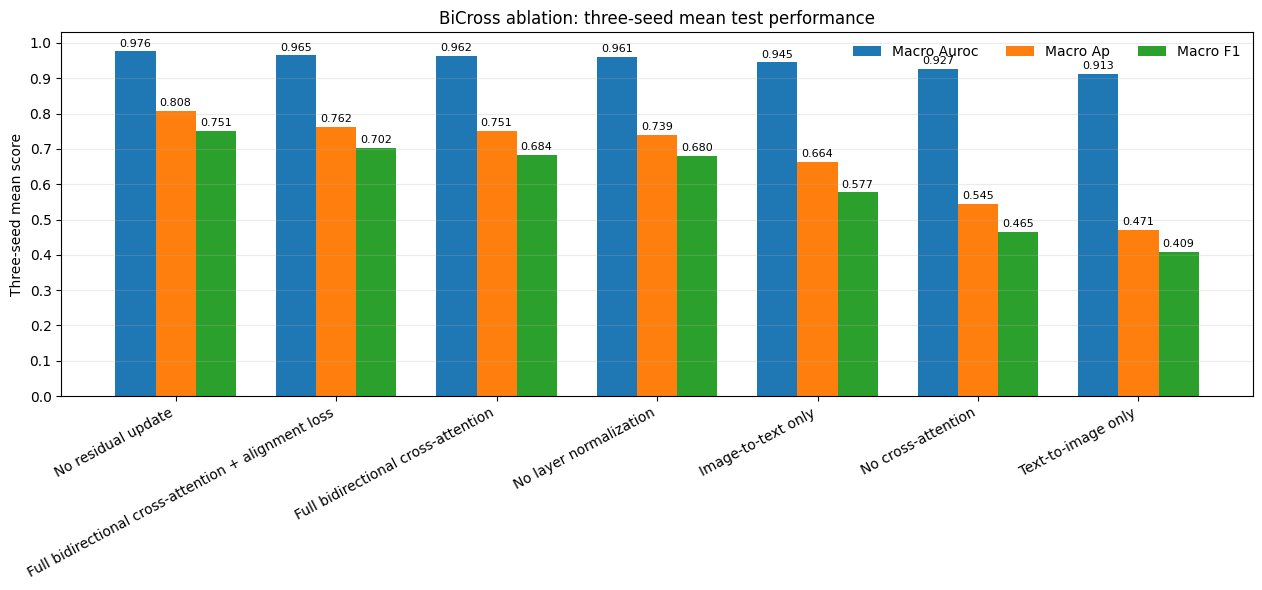

In [37]:
# Plot the full reference and every ablation with the score axis beginning at 0.4.
plot_mean_metrics(
    ablation_table,
    'BiCross ablation: three-seed mean test performance',
    'ablation_three_seed_mean.png',
    y_min=0,
)

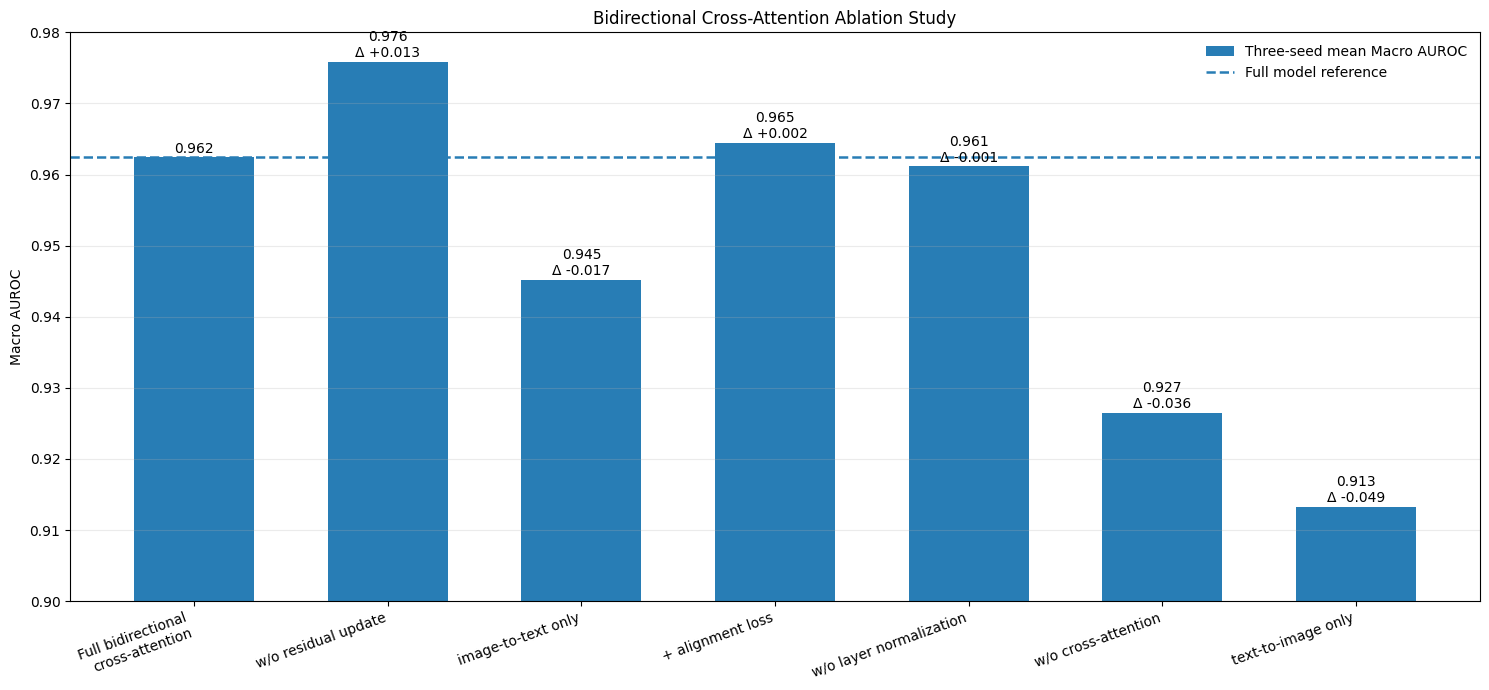

In [38]:
# Compare each ablation's Macro AUROC with the full-model reference.
ablation_auroc_order = [
    ('bidirectional_cross_attention', 'Full bidirectional\ncross-attention'),
    ('bicross_no_residual_update', 'w/o residual update'),
    ('bicross_i2t_only', 'image-to-text only'),
    ('bicross_with_alignment_loss', '+ alignment loss'),
    ('bicross_no_layer_norm', 'w/o layer normalization'),
    ('bicross_no_cross_attention', 'w/o cross-attention'),
    ('bicross_t2i_only', 'text-to-image only'),
]

ablation_auroc_lookup = ablation_table.set_index('model_key')['macro_auroc']
missing_auroc_models = [
    model_key
    for model_key, _ in ablation_auroc_order
    if model_key not in ablation_auroc_lookup.index
]
if missing_auroc_models:
    raise ValueError(
        f'Missing Macro AUROC results for: {missing_auroc_models}'
    )

ablation_auroc_labels = [label for _, label in ablation_auroc_order]
ablation_auroc_values = np.array([
    float(ablation_auroc_lookup.loc[model_key])
    for model_key, _ in ablation_auroc_order
])
full_model_auroc = ablation_auroc_values[0]
ablation_deltas = ablation_auroc_values - full_model_auroc

fig, ax = plt.subplots(figsize=(15, 7))
bars = ax.bar(
    np.arange(len(ablation_auroc_values)),
    ablation_auroc_values,
    width=0.62,
    color='#287DB5',
    label='Three-seed mean Macro AUROC',
)
ax.axhline(
    full_model_auroc,
    color='#287DB5',
    linestyle='--',
    linewidth=1.8,
    label='Full model reference',
)

for index, (bar, value, delta) in enumerate(
    zip(bars, ablation_auroc_values, ablation_deltas)
):
    annotation = f'{value:.3f}'
    if index != 0:
        annotation += f'\nΔ {delta:+.3f}'
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.0002,
        annotation,
        ha='center',
        va='bottom',
        fontsize=10,
    )

ax.set_xticks(np.arange(len(ablation_auroc_labels)))
ax.set_xticklabels(ablation_auroc_labels, rotation=20, ha='right')
ax.set_ylim(0.90, 0.98)
ax.set_yticks(np.arange(0.90, 0.981, 0.01))
ax.set_ylabel('Macro AUROC')
ax.set_title('Bidirectional Cross-Attention Ablation Study')
ax.grid(axis='y', alpha=0.25)
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    [handles[1], handles[0]],
    [labels[1], labels[0]],
    loc='upper right',
    frameon=False,
)
fig.tight_layout()
ablation_auroc_figure_path = (
    AVERAGED_DIR / 'ablation_macro_auroc_reference_comparison.png'
)
fig.savefig(ablation_auroc_figure_path, dpi=200, bbox_inches='tight')
plt.show()

In [39]:
# Display disease-level three-seed mean metrics for every ablation model.
ablation_per_label_mean = build_per_label_mean(ABLATION_MODEL_NAMES)
ablation_per_label_mean.to_csv(
    AVERAGED_DIR / 'ablation_three_seed_mean_per_label_metrics.csv',
    index=False,
)
display(ablation_per_label_mean.round(4))

,model_key,model,label,auroc,ap
0,bicross_i2t_only,Image-to-text only,Atelectasis,0.9801,0.7918
1,bicross_i2t_only,Image-to-text only,Cardiomegaly,0.9865,0.8510
2,bicross_i2t_only,Image-to-text only,Consolidation,0.8658,0.2668
3,bicross_i2t_only,Image-to-text only,Edema,0.9962,0.8542
4,bicross_i2t_only,Image-to-text only,Enlarged Cardiomediastinum,0.8801,0.0771
...,...,...,...,...,...
93,bidirectional_cross_attention,Full bidirectional cross-attention,Pleural Effusion,0.9810,0.8986
94,bidirectional_cross_attention,Full bidirectional cross-attention,Pleural Other,0.9945,0.7293
95,bidirectional_cross_attention,Full bidirectional cross-attention,Pneumonia,0.9790,0.6101
96,bidirectional_cross_attention,Full bidirectional cross-attention,Pneumothorax,0.9581,0.8261


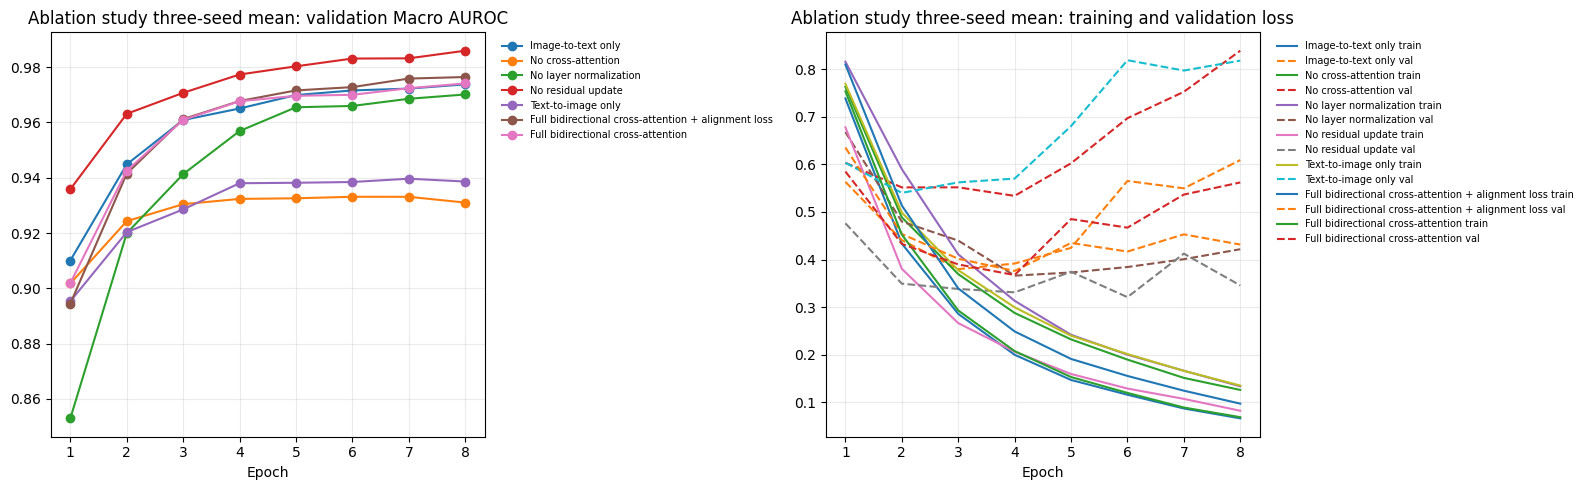

In [40]:
# Display the saved three-seed mean training histories for the ablation study.
ablation_mean_histories = show_mean_histories(
    ABLATION_MODEL_NAMES,
    filename_prefix='ablation',
    title_prefix='Ablation study three-seed mean',
)

## I2T fusion visualisation

The visualisation functions are imported from `src/medical_vlm/visualization/i2t.py`. Change the seed, split, sample index, or positive label directly in the cells below. Each call renders the four-panel heatmap under the current notebook cell and saves it to the selected seed's result folder when `SAVE_FIGURE=True`.

In [41]:
# Select one trained seed before importing the I2T visualisation module.
# Change this value to 42, 95, or 1024 before running this section.
I2T_SEED = 95
if I2T_SEED not in SEEDS:
    raise ValueError(f'I2T_SEED must be one of {SEEDS}.')

os.environ['MEDICAL_VLM_SEED'] = str(I2T_SEED)
src_path = str(PROJECT_DIR / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from medical_vlm.visualization.i2t import (
    find_positive_samples,
    load_i2t_visualisation_model,
    visualise_i2t_sample,
)

print('Selected I2T seed:', I2T_SEED)

Download already complete (14134513955 bytes).
Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/raddar/chest-xrays-indiana-university/versions/2


Indexing image files:   0%|          | 0/7470 [00:00<?, ?it/s]

Final df shape: (3666, 28)


,positive_count
No Finding,917.0
Lung Lesion,465.0
Lung Opacity,365.0
Atelectasis,303.0
Support Devices,258.0
Cardiomegaly,240.0
Pleural Effusion,199.0
Pneumonia,97.0
Fracture,92.0
Edema,78.0


,uid,filename,projection,text,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Lesion,Lung Opacity,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,1,1_IM-0001-4001.dcm.png,Frontal,Findings: The cardiac silhouette and mediastin...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2_IM-0652-1001.dcm.png,Frontal,Findings: Borderline cardiomegaly. Midline ste...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3,3_IM-1384-1001.dcm.png,Frontal,"Impression: No displaced rib fractures, pneumo...",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,4_IM-2050-1001.dcm.png,Frontal,Findings: There are diffuse bilateral intersti...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,5_IM-2117-1003002.dcm.png,Frontal,Findings: The cardiomediastinal silhouette and...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


...

preprocessor_config.json:   0%|          | 0.00/756 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/235k [00:00<?, ?B/s]

Tokenizer pad token: [PAD]
Number of labels: 14
train/val/test: 2566 550 550
pos_weight: {'No Finding': 3.066560983657837, 'Enlarged Cardiomediastinum': 20.0, 'Cardiomegaly': 14.551515579223633, 'Lung Lesion': 6.614243507385254, 'Lung Opacity': 8.869231224060059, 'Edema': 20.0, 'Consolidation': 20.0, 'Pneumonia': 20.0, 'Atelectasis': 11.046948432922363, 'Pneumothorax': 20.0, 'Pleural Effusion': 16.575342178344727, 'Pleural Other': 20.0, 'Fracture': 20.0, 'Support Devices': 12.576719284057617}
Selected I2T seed: 95


In [42]:
# Load the selected seed's trained image-to-text checkpoint.
i2t_model, i2t_checkpoint, i2t_checkpoint_path = (
    load_i2t_visualisation_model()
)

config.json:   0%|          | 0.00/879 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: microsoft/BiomedVLP-CXR-BERT-general
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded checkpoint: /content/drive/MyDrive/Dissertation/medical_vlm_fusion/artifacts/checkpoints/exp_seed_95/bicross_i2t_only_best.pt
Checkpoint epoch: 1


Saved heatmap: /content/drive/MyDrive/Dissertation/medical_vlm_fusion/artifacts/results/exp_seed_95/i2t_attention_visualisation/i2t_heatmap_test_0_uid_2.png


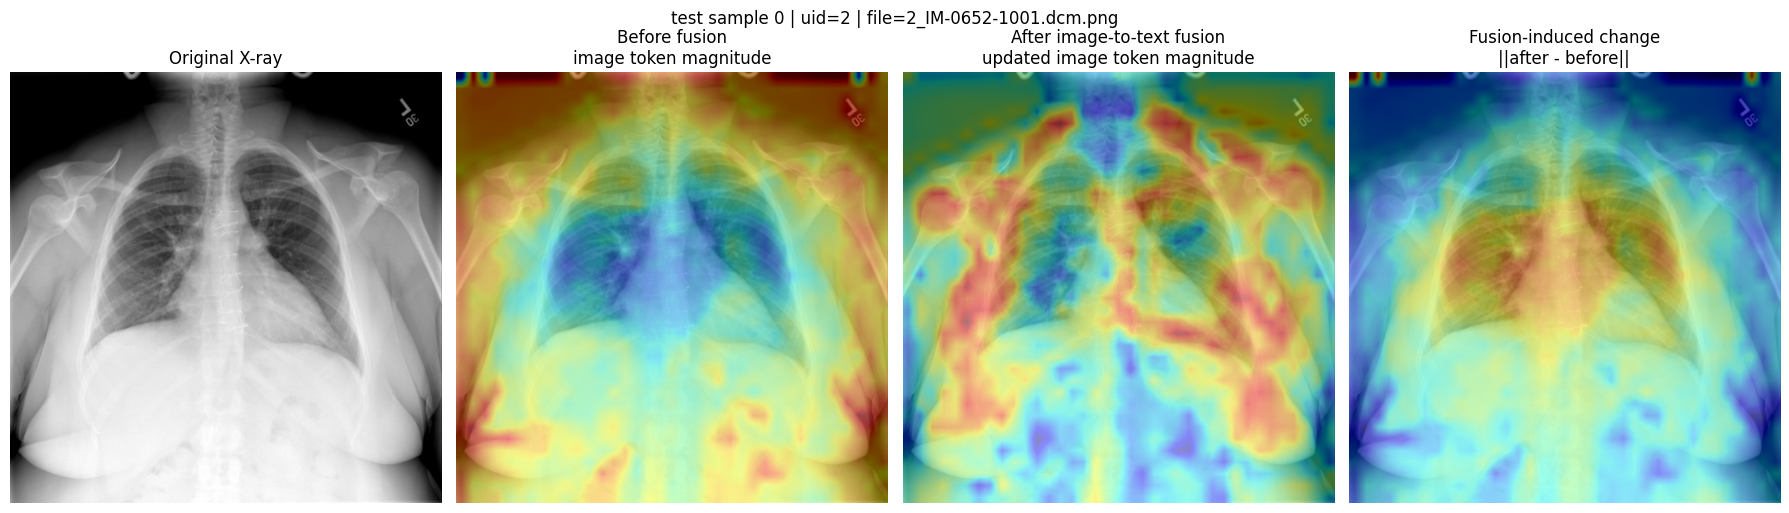

Report text:
Findings: Borderline cardiomegaly. Midline sternotomy XXXX. Enlarged pulmonary arteries. Clear lungs. Inferior XXXX XXXX XXXX. Impression: No acute pulmonary findings.

Ground-truth positive labels:
['Cardiomegaly', 'Support Devices']

Top predicted labels:


,label,probability
0,Cardiomegaly,0.606019
1,No Finding,0.493955
2,Support Devices,0.428245
3,Lung Lesion,0.418773
4,Lung Opacity,0.355974
5,Pleural Effusion,0.307558
6,Fracture,0.286024
7,Edema,0.279917



Text tokens most attended by image patches:


,token,attention_score
0,pulmonary,0.075444
1,arteries,0.047291
2,enlarged,0.046711
3,xx,0.040466
4,lungs,0.039903
5,xx,0.039453
6,##xx,0.038622
7,##xx,0.038398
8,##xx,0.037223
9,cardiomegaly,0.036503


In [43]:
# Visualise any sample by changing these three values.
SPLIT = 'test'       # Choose: 'train', 'validate', or 'test'.
SAMPLE_INDEX = 0     # Choose any valid row index from the selected split.
SAVE_FIGURE = True   # Save the rendered heatmap inside project artifacts.

vis_out = visualise_i2t_sample(
    sample_index=SAMPLE_INDEX,
    split=SPLIT,
    save=SAVE_FIGURE,
)

Found 10 test samples positive for Lung Opacity: [16, 18, 23, 25, 29, 31, 35, 54, 61, 67]
Saved heatmap: /content/drive/MyDrive/Dissertation/medical_vlm_fusion/artifacts/results/exp_seed_95/i2t_attention_visualisation/i2t_heatmap_test_16_uid_118.png


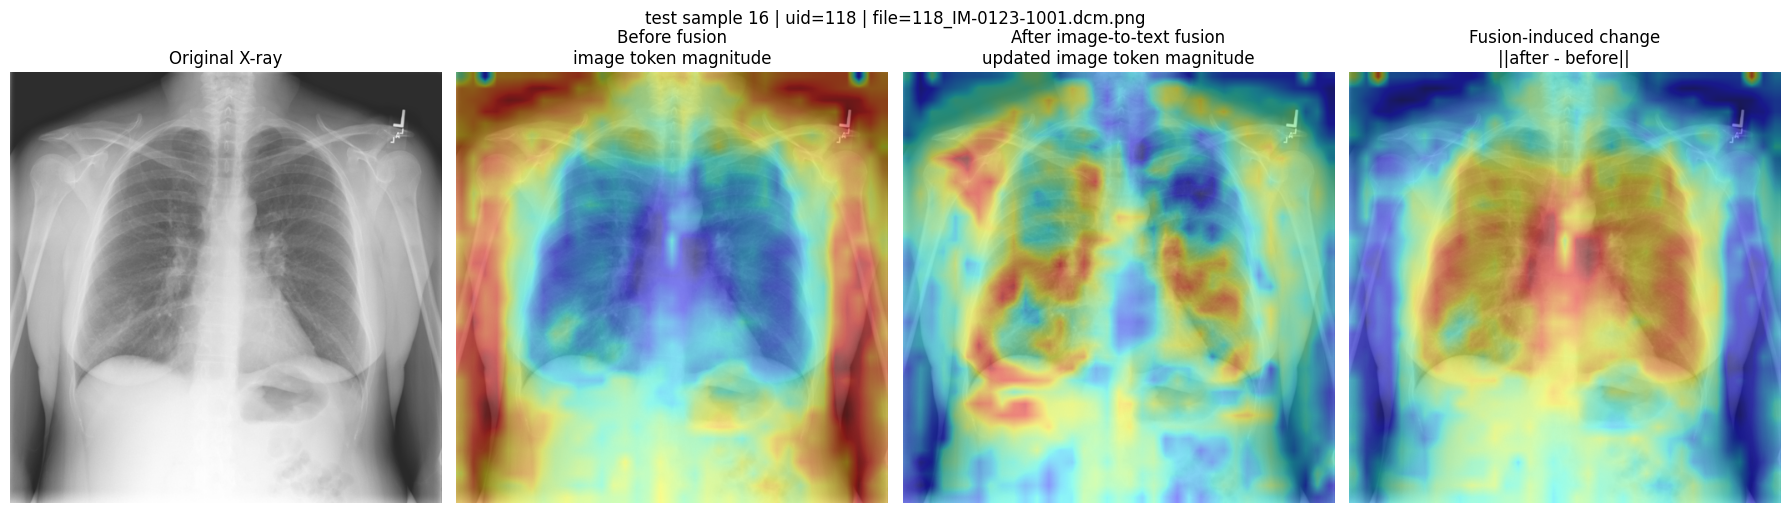

Report text:
Findings: The heart is normal in size and contour. There is focal airspace disease in the right middle lobe. There is no pneumothorax or effusion. Impression: Focal airspace disease in the right middle lobe. This is most concerning for pneumonia. Recommend follow up to ensure resolution.

Ground-truth positive labels:
['Lung Opacity', 'Pneumonia']

Top predicted labels:


,label,probability
0,Lung Opacity,0.849758
1,Pneumonia,0.829966
2,Atelectasis,0.826746
3,Lung Lesion,0.589211
4,Pleural Effusion,0.551150
5,Pneumothorax,0.477987
6,Support Devices,0.460491
7,Fracture,0.453206



Text tokens most attended by image patches:


,token,attention_score
0,lobe,0.054179
1,lobe,0.053628
2,pneumonia,0.053468
3,right,0.048633
4,focal,0.047345
5,right,0.046051
6,middle,0.040881
7,focal,0.040228
8,middle,0.039586
9,airspace,0.034277


In [44]:
# Find positive examples for a selected label and visualise one result.
LABEL_NAME = 'Lung Opacity'  # Choose any CheXpert-14 label.
SPLIT = 'test'               # Choose: 'train', 'validate', or 'test'.
MAX_CANDIDATES = 10
CANDIDATE_NUMBER = 0         # Select one item from the printed candidate list.
SAVE_FIGURE = True

candidate_indices = find_positive_samples(
    LABEL_NAME,
    split=SPLIT,
    max_n=MAX_CANDIDATES,
)
if not candidate_indices:
    raise ValueError(
        f'No positive {LABEL_NAME} sample was found in the selected {SPLIT} split.'
    )

selected_index = candidate_indices[CANDIDATE_NUMBER]
vis_out = visualise_i2t_sample(
    sample_index=selected_index,
    split=SPLIT,
    save=SAVE_FIGURE,
)

### Interpretation note

The heatmaps compare image patch representations before and after the image-to-text fusion layer. The delta map highlights where visual token representations changed most strongly after receiving information from report tokens. This is a model-behaviour visualisation, not proof of clinical causality.